#  Deep Learning Model for Pancreatic CT Scan Analysis

### Using U-Net for Medical Image Segmentation

**Name:** Arpita Padekar  
**Course:** Advanced Computing  
**Project Type:** Machine Learning + Medical Imaging

## 📌 Problem Statement

Pancreatic cancer is often diagnosed at advanced stages due to lack of early detection methods.
This project aims to develop a deep learning model using CT scan images to segment pancreatic regions
and assist in early risk detection.

The model uses U-Net architecture to identify pancreas regions from medical images.

##  Objective

- To preprocess CT scan data for deep learning
- To build a U-Net model for image segmentation
- To evaluate model performance using accuracy and Dice coefficient
- To support early detection using AI-based analysis

In [1]:
!pip install nibabel opencv-python-headless tensorflow matplotlib scikit-learn

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📂 Dataset

- Dataset: Pancreas CT Segmentation Dataset
- Format: .nii (3D medical images)
- Contains:
  - CT scan images (imagesTr)
  - Corresponding masks (labelsTr)

Each image is processed into 2D slices for model training.

In [7]:
import os
import numpy as np
import nibabel as nib
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [5]:
IMAGE_DIR = "/content/drive/MyDrive/Task07_Pancreas/imagesTr"
MASK_DIR  = "/content/drive/MyDrive/Task07_Pancreas/labelsTr"

IMG_SIZE = 128

## 🧰 Libraries Used

- TensorFlow / Keras
- NumPy
- OpenCV
- Nibabel (for medical images)
- Matplotlib
- Scikit-learn

## ⚙ Data Preprocessing

- Conversion of 3D CT scans to 2D slices
- Image resizing (128 × 128)
- Normalization (pixel values scaled to 0–1)
- Binary mask conversion
- Train-test split

In [8]:
images = []
masks = []

image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.nii.gz')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.nii.gz')])

for img_file, mask_file in zip(image_files, mask_files):
    try:
        img = nib.load(os.path.join(IMAGE_DIR, img_file)).get_fdata()
        mask = nib.load(os.path.join(MASK_DIR, mask_file)).get_fdata()

        slice_idx = img.shape[2] // 2

        img_slice = img[:, :, slice_idx]
        mask_slice = mask[:, :, slice_idx]

        img_slice = cv2.resize(img_slice, (IMG_SIZE, IMG_SIZE))
        mask_slice = cv2.resize(mask_slice, (IMG_SIZE, IMG_SIZE))

        img_slice = img_slice / np.max(img_slice)
        mask_slice = (mask_slice > 0).astype(np.float32)

        img_slice = np.stack((img_slice,) * 3, axis=-1)
        mask_slice = np.expand_dims(mask_slice, axis=-1)

        images.append(img_slice)
        masks.append(mask_slice)

    except:
        continue

images = np.array(images)
masks = np.array(masks)

print("Images:", images.shape)
print("Masks:", masks.shape)

Images: (178, 128, 128, 3)
Masks: (178, 128, 128, 1)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

## 🧠 Model Architecture – U-Net

U-Net is a convolutional neural network designed for biomedical image segmentation.

It consists of:
- Encoder (downsampling)
- Bottleneck
- Decoder (upsampling)

The model predicts pixel-wise segmentation masks.

In [10]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )

def build_unet(input_shape=(128,128,3)):

    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

    u1 = layers.UpSampling2D()(b)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

model = build_unet()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coef]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,537 (724.75 KB)

 Trainable params: 185,537 (724.75 KB)

 Non-trainable params: 0 (0.00 B)

## 🚀 Model Training

- Loss Function: Binary Crossentropy
- Optimizer: Adam
- Metrics: Accuracy, Dice Coefficient
- Epochs: 10
- Batch Size: 8

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9917 - dice_coef: 0.0137 - loss: 0.1398 - val_accuracy: 0.9911 - val_dice_coef: 0.0254 - val_loss: 0.0520
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9917 - dice_coef: 0.0512 - loss: 0.0443 - val_accuracy: 0.9911 - val_dice_coef: 0.0349 - val_loss: 0.0418
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9917 - dice_coef: 0.0412 - loss: 0.0379 - val_accuracy: 0.9911 - val_dice_coef: 0.0497 - val_loss: 0.0382
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9917 - dice_coef: 0.0465 - loss: 0.0358 - val_accuracy: 0.9911 - val_dice_coef: 0.0484 - val_loss: 0.0372
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9917 - dice_coef: 0.0491 - loss: 0.0349 - val_accuracy: 0.9911 - val_dice_coef: 0.0452 - val_loss: 0.0368


## 📊 Results

The model outputs segmented pancreas regions from CT images.

Below is a comparison of:
- Original CT image
- Ground truth mask
- Predicted mask

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step


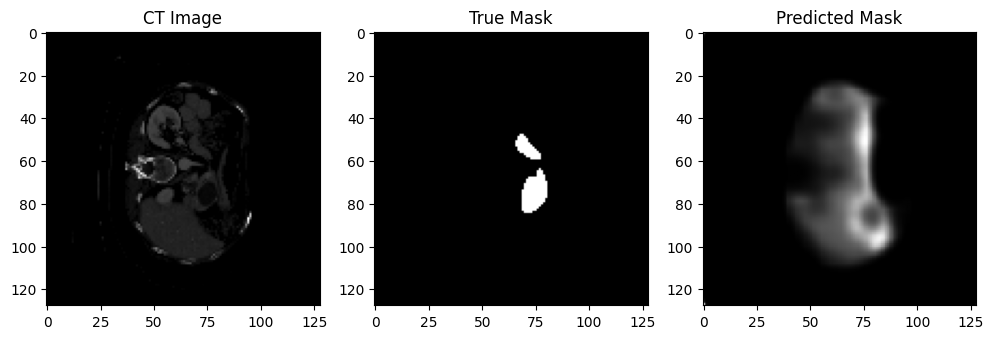

In [12]:
pred = model.predict(X_test[:1])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("CT Image")
plt.imshow(X_test[0])

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(y_test[0].squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred[0].squeeze(), cmap='gray')

plt.show()

## ✅ Conclusion

The U-Net model successfully performs segmentation of pancreatic regions from CT scans.

This approach can support early detection systems and can be extended by integrating
biomarker-based analysis and AI-driven diagnostics.

## 🔮 Future Scope

- Integration with biosensor-based detection (CA19-9)
- Multi-modal AI system (biomarker + imaging)
- Improved accuracy using advanced architectures
- Real-time clinical decision support system